# User Study — Evaluation Plots

This notebook generates all plots for the user-study evaluation (participant
background and Likert-scale survey results for App A vs. App B).

Each plot lives in its own cell. Every plot is saved in two formats:

- **PDF** → `output/figures/` (for quick viewing)
- **TikZ / PGFPlots `.tex`** → `output/tikz/` (via `tikzplotlib`, for direct
  `\input{}` into the LaTeX thesis)

**Data sources** (in `../data/`):

- `background.csv` — participant background survey
- `appA.csv`, `appB.csv` — Likert-scale feedback per app

Run all cells top to bottom (`Run All`) to (re-)generate every figure.

In [1]:
import re
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tikzplotlib
from pathlib import Path

%matplotlib inline

PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "results" / "form-results"
FIGURES_DIR = PROJECT_ROOT / "output" / "figures"
TIKZ_DIR = PROJECT_ROOT / "output" / "tikz"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TIKZ_DIR.mkdir(parents=True, exist_ok=True)

# tikzplotlib only LaTeX-escapes axis titles/labels/ticklabels, not plain
# ax.text() content (e.g. our "86%" bar labels or "A & B" style headers).
# A bare "%" or "&" in a \node{...} silently breaks the .tex file: "%"
# starts a LaTeX comment that swallows the rest of the line (including the
# closing brace), which only surfaces much later as confusing "Missing }
# inserted" / "Extra }, or forgotten \endgroup" errors. Escape those
# characters ourselves, only inside the `]{...};` node-text blocks that
# tikzplotlib emits for ax.text()/set_title(loc=...) calls.
_TIKZ_NODE_TEXT_RE = re.compile(r"(\]\{)([^{}]*)(\};)")
_LATEX_SPECIAL_CHARS = {"%": r"\%", "&": r"\&", "#": r"\#", "_": r"\_"}


def _escape_latex(text):
    for char, escaped in _LATEX_SPECIAL_CHARS.items():
        text = re.sub(rf"(?<!\\){re.escape(char)}", escaped, text)
    return text


def _sanitize_tikz_code(tikz_code):
    return _TIKZ_NODE_TEXT_RE.sub(
        lambda m: f"{m.group(1)}{_escape_latex(m.group(2))}{m.group(3)}", tikz_code
    )


# Rotated tick labels (matplotlib's usual trick for long category names) are
# a poor fit for TikZ export: pgfplots' automatic bounding-box computation
# under-estimates how far rotated text extends, so even `\resizebox` doesn't
# reliably keep it inside a narrow subfigure column, and it visually spills
# into the next one. Wrapping labels onto short horizontal lines instead
# gives a predictable footprint (roughly one word's width per line), which
# never depends on pgfplots' bounding-box quirks.
# A few labels need a specific split to keep every resulting line short
# enough that neighbouring categories' labels don't touch once centered
# under their own (narrowly spaced) tick in a half-page-wide chart.
_WRAP_OVERRIDES = {
    "Technical / Computer Science": "Technical /\nComputer\nScience",
}


def _wrap_label(label, threshold=12):
    if label in _WRAP_OVERRIDES:
        return _WRAP_OVERRIDES[label]
    if len(label) <= threshold:
        return label
    if " / " in label:
        left, right = label.split(" / ", 1)
        return f"{left} /\n{right}"
    words = label.split(" ")
    mid = len(words) // 2
    return " ".join(words[:mid]) + "\n" + " ".join(words[mid:])


# tikzplotlib passes a Python "\n" in a tick label straight through as a
# literal newline inside `xticklabels={...}`, which (La)TeX just reads as a
# space, not a line break, so it does nothing useful. Turn embedded newlines
# into a real TeX line break instead.
_XTICKLABELS_RE = re.compile(r"(xticklabels=\{)(.*?)(\},)", re.DOTALL)


def _fix_multiline_ticklabels(tikz_code):
    def repl(match):
        return match.group(1) + match.group(2).replace("\n", r" \\ ") + match.group(3)

    return _XTICKLABELS_RE.sub(repl, tikz_code)


def _fit_likert_comparison_tikz(tikz_code):
    """Make the Likert comparison TikZ match the PDF page footprint.

    pgfplots under-estimates long y-tick labels by ~86pt, so width=\\linewidth
    alone overflows the text block (~82pt overfull \\hbox). Subtract that
    slack so the final bounding box equals \\linewidth — same footprint as
    \\includegraphics[width=\\linewidth]{likert_comparison.pdf}. Also pin
    integer Likert ticks and an open L-frame to match the PDF styling.
    """
    tikz_code = tikz_code.replace(
        r"width=\linewidth",
        r"width=\dimexpr\linewidth-86pt\relax",
    )
    # Insert PDF-matching axis options once, right after clip=false.
    if "xtick={1,2,3,4,5}" not in tikz_code:
        tikz_code = tikz_code.replace(
            "clip=false,",
            "clip=false,\n"
            "xtick={1,2,3,4,5},\n"
            "axis x line=bottom,\n"
            "axis y line=left,\n"
            "axis line style={-},",
        )
    return tikz_code


def save_figure(fig, name, height_ratio=None, height_abs=None, multiline_xticklabels=False):
    """Save a figure as a standalone PDF and as a TikZ/PGFPlots .tex file.

    The PDF goes to output/figures/<name>.pdf, the TikZ source to
    output/tikz/<name>.tex, ready to be included in the thesis with
    \\input{output/tikz/<name>.tex}.

    Every figure gets width=\\linewidth: without this, pgfplots falls back
    to a fixed default axis size regardless of where the file is
    \\input/\\included, which overflows narrow containers (e.g. a
    0.48\\textwidth subfigure) and looks inconsistent if the same file is
    reused at different widths.

    height_ratio is the axis height as a multiple of \\linewidth, so the
    whole thing scales together and keeps its aspect ratio. This is the
    default (computed from the figure's own aspect ratio if not given).

    height_abs is an *absolute* axis height (e.g. "0.95in") instead, for
    multi-panel groupplots with per-row decorations (titles, headers, ...)
    at fixed point sizes: those need a physical minimum height per panel
    regardless of container width, or the fixed-size text starts
    overlapping (see PAGES/make_page below for a case where this bit us).

    multiline_xticklabels should be True for charts built with _wrap_label,
    so the exported .tex both fixes up the embedded newlines and centers
    the resulting lines under each tick.
    """
    pdf_path = FIGURES_DIR / f"{name}.pdf"
    tex_path = TIKZ_DIR / f"{name}.tex"
    fig.savefig(pdf_path, format="pdf", bbox_inches="tight")

    extra_axis_parameters = {"clip=false"}
    if multiline_xticklabels:
        # \tiny: with only ~3-4 categories sharing a half-page-wide axis,
        # the default document font size leaves too little horizontal room
        # per category, so adjacent (even wrapped) labels start touching.
        extra_axis_parameters.add("xticklabel style={align=center,font=\\tiny}")

    if height_abs is not None:
        axis_height = height_abs
    else:
        if height_ratio is None:
            fig_width_in, fig_height_in = fig.get_size_inches()
            height_ratio = fig_height_in / fig_width_in
        axis_height = f"{height_ratio:.4f}\\linewidth"
    tikz_code = tikzplotlib.get_tikz_code(
        figure=fig,
        axis_width=r"\linewidth",
        axis_height=axis_height,
        extra_axis_parameters=extra_axis_parameters,
    )
    tikz_code = _sanitize_tikz_code(tikz_code)
    if multiline_xticklabels:
        tikz_code = _fix_multiline_ticklabels(tikz_code)
    if name == "likert_comparison":
        tikz_code = _fit_likert_comparison_tikz(tikz_code)
    tex_path.write_text(tikz_code)
    print(f"Saved {pdf_path.relative_to(PROJECT_ROOT)} and {tex_path.relative_to(PROJECT_ROOT)}")

## 1. Participant Background

Bar charts summarising the participants' professional background, software
development experience, self-assessed programming skills, and how often they
use AI tools/chatbots at work (`data/background.csv`).

In [2]:
# --- Load & clean background data ---
bg_raw = pd.read_csv(DATA_DIR / "background.csv", sep=";", encoding="utf-8")

# Col 4: Professional Background, Col 5: Programming Experience, Col 6: Self-Assessment,
# Col 7: AI Tool Usage
bg_df = bg_raw.iloc[:, [4, 5, 6, 7]].copy()
bg_df.columns = [
    "Professional Background",
    "Experience in Software Development Field",
    "Self Assessed Programming Skills",
    "AI Tool Usage at Work",
]

# Normalise known typos / capitalisation / encoding artefacts in the data
TYPO_FIX = {
    "Grundkentnisse": "Basic Knowledge",
    "keine Erfahrung": "No Experience",
    # Corrupted en-dashes (U+2013 → U+FFFD) in the CSV
    "1\ufffd3 Jahre": "1–3 Years",
    "3\ufffd5 Jahre": "3–5 Years",
    # Translate remaining German values
    "Mehr als 5 Jahre": "More than 5 Years",
    "Fortgeschritten": "Advanced",
    "Experte": "Expert",
    "Technisch / Informatik": "Technical / Computer Science",
    "Business / Produkt": "Business / Product",
    # Corrupted umlauts (U+00F6/U+00E4 → U+FFFD) in the CSV
    "W\ufffdchentlich": "Weekly",
    "T\ufffdglich": "Daily",
}
for col in bg_df.columns:
    bg_df[col] = bg_df[col].map(lambda v: TYPO_FIX.get(str(v), v))

# Fixed category order (matches the original form scales)
ORDER_BACKGROUND = ["Technical / Computer Science", "Business / Product", "Design / UX"]
ORDER_EXPERIENCE = ["1–3 Years", "3–5 Years", "More than 5 Years"]
ORDER_SKILLS = ["No Experience", "Basic Knowledge", "Advanced", "Expert"]
ORDER_AI_USAGE = ["Weekly", "Daily"]

plt.rcParams.update({
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


def plot_counts(column, order, color="#4C72B0"):
    counts = bg_df[column].value_counts().reindex(order, fill_value=0)
    # Wrapped, horizontal labels instead of rotated ones: see _wrap_label's
    # docstring comment for why rotation doesn't survive the TikZ export well.
    labels = [_wrap_label(cat) for cat in counts.index]
    fig, ax = plt.subplots(figsize=(6, 3.5))
    bars = ax.bar(labels, counts.values, color=color, edgecolor="black", linewidth=0.6)
    ax.set_ylabel("Number of Participants")
    ax.set_ylim(0, max(counts.values) + 1)
    ax.set_yticks(range(0, max(counts.values) + 2))
    ax.tick_params(axis="x", pad=6)
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, h + 0.05, int(h),
                    ha="center", va="bottom", fontsize=10)
    fig.tight_layout()
    return fig

Saved output/figures/professional_background.pdf and output/tikz/professional_background.tex


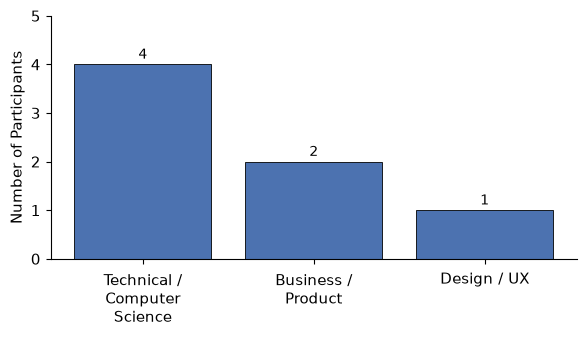

In [3]:
# Plot: Professional Background
fig = plot_counts("Professional Background", ORDER_BACKGROUND)
save_figure(fig, "professional_background", multiline_xticklabels=True)

Saved output/figures/programming_experience.pdf and output/tikz/programming_experience.tex


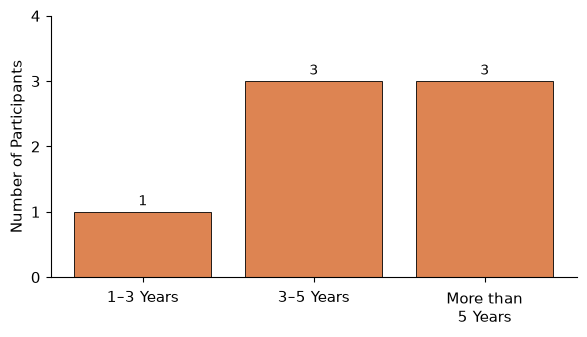

In [4]:
# Plot: Experience in Software Development Field
fig = plot_counts("Experience in Software Development Field", ORDER_EXPERIENCE, color="#DD8452")
save_figure(fig, "programming_experience", multiline_xticklabels=True)

Saved output/figures/self_assessment.pdf and output/tikz/self_assessment.tex


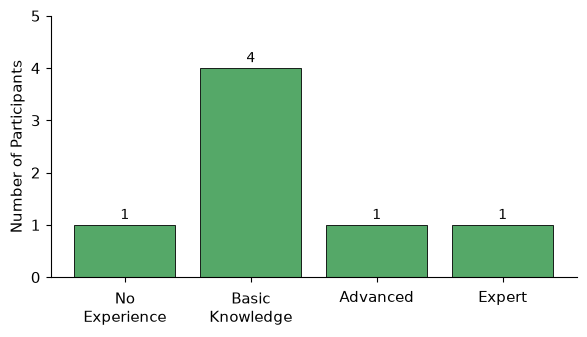

In [5]:
# Plot: Self Assessed Programming Skills
fig = plot_counts("Self Assessed Programming Skills", ORDER_SKILLS, color="#55A868")
save_figure(fig, "self_assessment", multiline_xticklabels=True)

Saved output/figures/ai_tool_usage.pdf and output/tikz/ai_tool_usage.tex


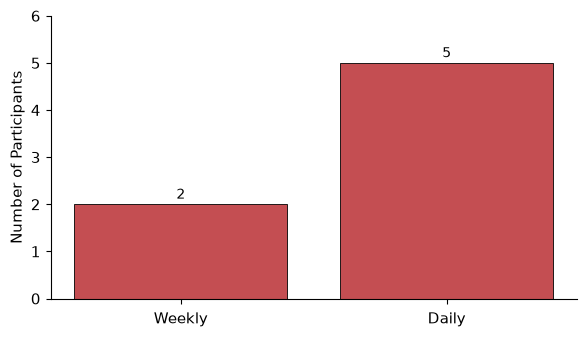

In [6]:
# Plot: AI Tool Usage at Work
fig = plot_counts("AI Tool Usage at Work", ORDER_AI_USAGE, color="#C44E52")
save_figure(fig, "ai_tool_usage", multiline_xticklabels=True)

## 2. Likert-Scale Survey Data (App A vs. App B)

Loads and maps the German Likert-scale answers (`data/appA.csv`,
`data/appB.csv`) to numeric scores 1–5. This shared data is used by both the
mean-comparison plot and the distribution plots below.

In [7]:
# --- Load CSV data & map to numeric ---
# Likert columns: 4-15 (items 1.1–4.3) + 19 (6.1 overall)
LIKERT_COLS = list(range(4, 16)) + [19]

raw_a = pd.read_csv(DATA_DIR / "appA.csv", sep=";", encoding="utf-8").iloc[:, LIKERT_COLS]
raw_b = pd.read_csv(DATA_DIR / "appB.csv", sep=";", encoding="utf-8").iloc[:, LIKERT_COLS]

# --- Map German Likert text → numeric 1-5 ---
FIRST_IMPRESSION_MAP = {
    "sehr negativ": 1, "negativ": 2, "neutral": 3, "positiv": 4, "sehr positiv": 5,
}
AGREEMENT_MAP = {
    "stimme gar nicht zu": 1, "stimme nicht zu": 2, "weder noch": 3,
    "stimme zu": 4, "stimme voll zu": 5,
}
SATISFACTION_MAP = {
    "sehr unzufrieden": 1, "unzufrieden": 2, "neutral": 3,
    "zufrieden": 4, "sehr zufrieden": 5,
}


def parse_likert(series: pd.Series, col_idx: int) -> pd.Series:
    """Choose the right mapping: col 0 = first impression, col 12 = satisfaction."""
    if col_idx == 0:       # 1.1  First impression
        return series.map(FIRST_IMPRESSION_MAP)
    elif col_idx == 12:    # 6.1  Overall satisfaction
        return series.map(SATISFACTION_MAP)
    else:                  # 1.2 – 4.3  Agreement scale
        return series.map(AGREEMENT_MAP)


app_a = pd.DataFrame({i: parse_likert(raw_a.iloc[:, i], i) for i in range(13)})
app_b = pd.DataFrame({i: parse_likert(raw_b.iloc[:, i], i) for i in range(13)})

# --- Item labels (short) & section groups ---
items = [
    # Section: First Impression
    "1.1 First Impression",
    "1.2 Professional Design",
    # Section: Visual Consistency & Design
    "2.1 Colour Consistency",
    "2.2 Font Readability",
    "2.3 Text Contrast",
    "2.4 Button Consistency",
    "2.5 Layout Cleanliness",
    # Section: Usability & Navigation
    "3.1 Ease of Use",
    "3.2 Navigation Clarity",
    # Section: Functionality & Answer Quality
    "4.1 Answer Relevance",
    "4.2 Answer Correctness",
    "4.3 Edge-Case Handling",
    # Section: Overall
    "6.1 Overall Satisfaction",
]

app_a.columns = items
app_b.columns = items

### 2.1 Mean Comparison — Dot Plot

Per-item mean Likert score for App A vs. App B, with jittered individual
participant responses and section groupings.

Saved output/figures/likert_comparison.pdf and output/tikz/likert_comparison.tex


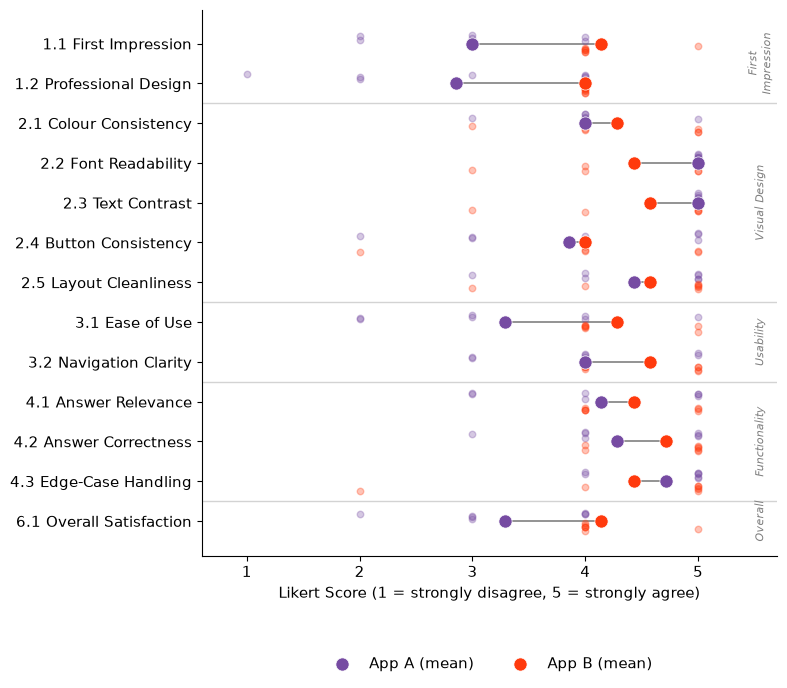

In [8]:
# Section boundaries (row indices between groups, for horizontal lines)
section_boundaries = [2, 7, 9, 12]  # after First Impression, Design, Usability, Functionality

# Section labels for right-side annotations: (start_row, end_row, label)
sections = [
    (0, 2,  "First\nImpression"),
    (2, 7,  "Visual Design"),
    (7, 9,  "Usability"),
    (9, 12, "Functionality"),
    (12, 13, "Overall"),
]

mean_a, mean_b = app_a.mean(), app_b.mean()

fig, ax = plt.subplots(figsize=(8, 7))
y = np.arange(len(items))

# Section separator lines
for boundary in section_boundaries:
    ax.axhline(y=boundary - 0.5, color="lightgrey", lw=1, zorder=0)

# Section group labels (right side)
for start, end, label in sections:
    mid = (start + end - 1) / 2
    ax.text(5.55, mid, label, ha="center", va="center", fontsize=8,
            color="grey", style="italic", rotation=90)

# Individual participant points (jittered)
rng = np.random.default_rng(1)
for i in range(len(items)):
    jitter_a = rng.uniform(-0.1, 0.1, size=len(app_a))
    jitter_b = rng.uniform(-0.1, 0.1, size=len(app_b))
    ax.scatter(app_a.iloc[:, i], np.full(len(app_a), i - 0.15) + jitter_a,
               color="#764ba2", alpha=0.3, s=22, zorder=2)
    ax.scatter(app_b.iloc[:, i], np.full(len(app_b), i + 0.15) + jitter_b,
               color="#ff3a0d", alpha=0.3, s=22, zorder=2)

# Connecting line between means
for i in range(len(items)):
    ax.plot([mean_a.iloc[i], mean_b.iloc[i]], [i, i],
            color="grey", lw=1.2, zorder=1)

# Mean markers
ax.scatter(mean_a, y, color="#764ba2", s=90, label="App A (mean)", zorder=3,
           edgecolors="white", linewidths=0.5)
ax.scatter(mean_b, y, color="#ff3a0d", s=90, label="App B (mean)", zorder=3,
           edgecolors="white", linewidths=0.5)

ax.set_yticks(y)
ax.set_yticklabels(items)
ax.invert_yaxis()
ax.set_xlim(0.6, 5.7)
ax.set_xticks([1, 2, 3, 4, 5])
ax.set_xlabel("Likert Score (1 = strongly disagree, 5 = strongly agree)")
# y=-0.16 (not -0.08): pgfplots places the xlabel independently of the
# legend's "at" offset, so a smaller magnitude here visually overlaps the
# xlabel once exported to TikZ (matplotlib's own layout avoids this via
# tight_layout, which pgfplots has no equivalent of). -0.16 leaves a clean
# gap from full \textwidth down to about 0.65\textwidth; this chart has 13
# categories plus a legend, so don't squeeze it much narrower than that in
# either the PDF or TikZ version, or the row labels get cramped too.
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.16), ncol=2, frameon=False)
ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
save_figure(fig, "likert_comparison")

### 2.2 Response Distributions — Diverging Stacked Bars

Per-item distribution of responses (1–5) for App A vs. App B, split across
two pages for readability.

In [9]:
# --- Shared config & helpers for the distribution plots ---
COLORS = ["#c0392b", "#e67e22", "#bdc3c7", "#7fb3d5", "#2471a3"]
LEGEND_LABELS = ["1 — Strongly Disagree", "2 — Disagree", "3 — Neutral",
                 "4 — Agree", "5 — Strongly Agree"]
APP_A_COLOR = "#764ba2"
APP_B_COLOR = "#ff3a0d"
# Item title / section header y-positions, in the same data coordinates as
# the bars (which sit at y=0 and y=1). These used to be placed via a
# transAxes-plus-points offset_copy transform, which matplotlib renders
# correctly but tikzplotlib cannot translate: it collapses any such custom
# transform to the nearest data coordinate, so the title and header both
# ended up stamped on top of each other in the exported .tex regardless of
# the real intended offset. Plain data coordinates avoid that entirely.
TITLE_Y = 1.5
HEADER_Y = 1.9

ROW_HEIGHT = 1.0
TOP_EXTRA = 0.3
BOTTOM_EXTRA = 1.3

# Page 1 = Sections 1-2 (First Impression, Visual Consistency & Design)
# Page 2 = Sections 3-6 (Usability & Navigation, Functionality & Answer
# Quality, Overall Satisfaction)
PAGES = [
    {
        "items": items[0:7],
        "sections": [
            ("First Impression",            0, 2),
            ("Visual Consistency & Design", 2, 7),
        ],
        "name": "likert_distributions_part1",
    },
    {
        "items": items[7:13],
        "sections": [
            ("Usability & Navigation",         0, 2),
            ("Functionality & Answer Quality", 2, 5),
            ("Overall Satisfaction",           5, 6),
        ],
        "name": "likert_distributions_part2",
    },
]


def add_section_grouping(fig, ax_list, spans):
    """Small caps section-name label above the first item title of each
    section."""
    for title, start, end in spans:
        ax_top = ax_list[start]
        ax_top.text(0, HEADER_Y, title.upper(), fontsize=7.5, fontweight="bold",
                    color="#8a8a8a", style="italic", va="bottom", ha="left")


def make_page(page_items, section_spans):
    nrows = len(page_items)
    fig, axes = plt.subplots(nrows, 1,
                              figsize=(7.5, ROW_HEIGHT * nrows + TOP_EXTRA + BOTTOM_EXTRA),
                              squeeze=False)
    axes = axes[:, 0]

    for ax, item in zip(axes, page_items):
        pct_a = app_a[item].value_counts().reindex(range(1, 6), fill_value=0).values
        pct_a = pct_a / pct_a.sum() * 100
        pct_b = app_b[item].value_counts().reindex(range(1, 6), fill_value=0).values
        pct_b = pct_b / pct_b.sum() * 100

        for row_idx, pct in enumerate([pct_b, pct_a]):
            left = 0
            for val, color in zip(pct, COLORS):
                ax.barh(row_idx, val, left=left, color=color, edgecolor="white",
                        height=0.5)
                if val > 10:
                    ax.text(left + val / 2, row_idx, f"{val:.0f}%",
                            ha="center", va="center", fontsize=7)
                left += val

        ax.set_xlim(0, 102)
        # A plain data-coordinate ax.text() instead of ax.set_title(loc="left"):
        # matplotlib's own title placement uses a transform tikzplotlib can't
        # translate either, so it suffers the exact same collapse-to-one-point
        # issue described above for the section header.
        ax.text(0, TITLE_Y, item, fontsize=9, fontweight="bold", va="bottom", ha="left")
        ax.spines[["top", "right"]].set_visible(False)
        ax.tick_params(labelsize=7)
        # Hide y-tick labels (redundant across all rows). Using
        # labelleft=False rather than set_yticklabels([]) so tikzplotlib
        # correctly detects the labels as absent instead of re-emitting
        # pgfplots' auto-generated "0"/"1" labels in the exported .tex.
        ax.set_yticks([0, 1])
        ax.tick_params(axis="y", labelleft=False)

        ax.text(-1.5, 1, "B", fontsize=8, fontweight="bold", color=APP_B_COLOR,
                va="center", ha="right")
        ax.text(-1.5, 0, "A", fontsize=8, fontweight="bold", color=APP_A_COLOR,
                va="center", ha="right")

    add_section_grouping(fig, axes, section_spans)

    # Dummy zero-width bars so tikzplotlib can export the legend entries
    # (it cannot export a fig.legend() built from bare Rectangle handles).
    last_ax = axes[-1]
    for color, label in zip(COLORS, LEGEND_LABELS):
        last_ax.barh(0, 0, left=0, color=color, edgecolor="white", label=label)
    last_ax.legend(loc="upper center", ncol=5, frameon=False, fontsize=7.5,
                   bbox_to_anchor=(0.5, -1.9), bbox_transform=last_ax.transAxes)

    fig.supxlabel("% of Responses", fontsize=9, y=0.035)

    fig.subplots_adjust(left=0.09, right=0.95, top=0.97, bottom=0.075,
                        hspace=1.6)
    return fig

Saved output/figures/likert_distributions_part1.pdf and output/tikz/likert_distributions_part1.tex


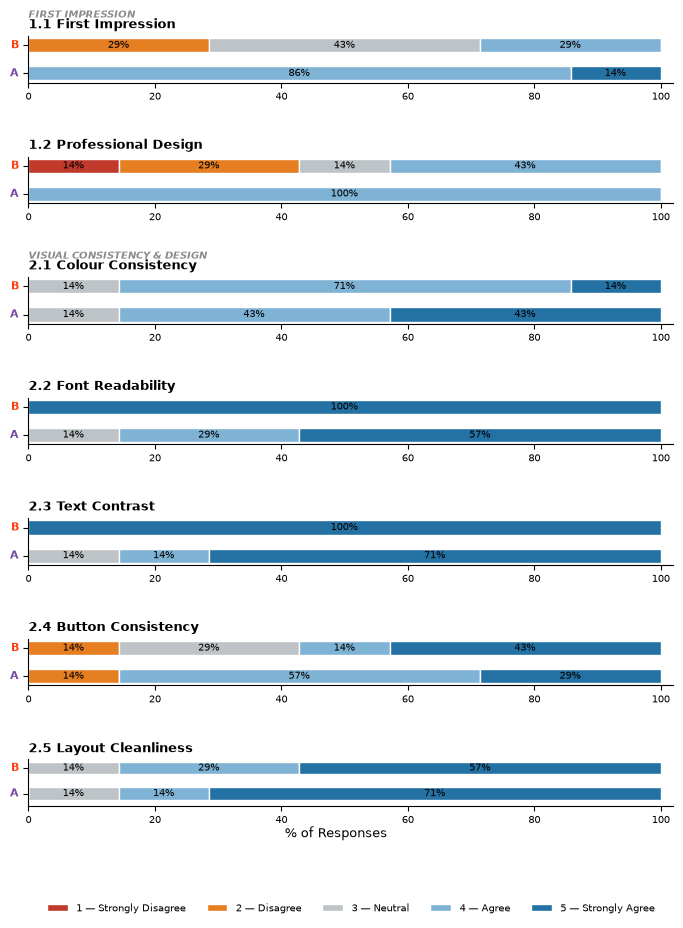

In [10]:
# Plot: Response distributions, page 1 (First Impression, Visual Consistency & Design)
page = PAGES[0]
fig = make_page(page["items"], page["sections"])
save_figure(fig, page["name"], height_abs="0.95in")

Saved output/figures/likert_distributions_part2.pdf and output/tikz/likert_distributions_part2.tex


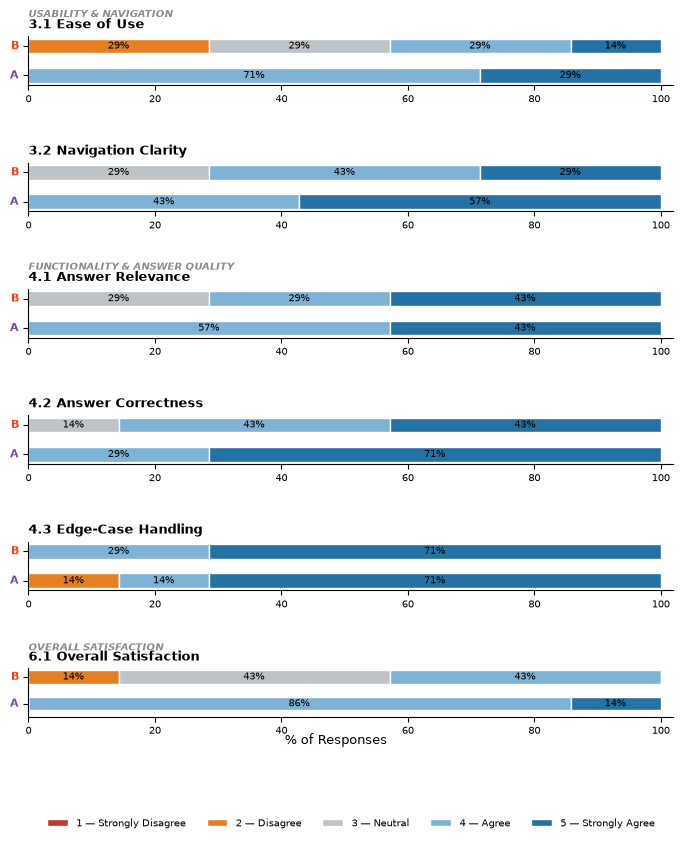

In [11]:
# Plot: Response distributions, page 2 (Usability & Navigation, Functionality & Answer Quality, Overall Satisfaction)
page = PAGES[1]
fig = make_page(page["items"], page["sections"])
save_figure(fig, page["name"], height_abs="0.95in")